In [64]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [65]:
class BatsmanState(TypedDict):
    runs: int
    fours: int
    sixes: int
    balls: int
    
    sr: float
    boundary_percent: float
    bpb: float
    summary: str

In [66]:
def calculate_sr(state: BatsmanState):
    sr = (state['runs']/state['balls'])*100

    return {'sr' : sr}

In [67]:
def calculate_boundary_percent(state: BatsmanState):
    boundary_percent = (((state['fours']*4)+(state['sixes']*6))/(state['runs']))

    return {'boundary_percent': boundary_percent}

In [68]:
def calculate_bpb(state: BatsmanState):
    bpb = state['balls']/(state['fours']+state['sixes'])

    return {'bpb': bpb}

In [69]:
def summary(state: BatsmanState):
    summary = f"""
Strike Rate- {state['sr']} \n
Boundary percent - {state['boundary_percent']} \n
Balls Per boundary - {state['bpb']}
"""
    return {'summary': summary}

In [70]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_boundary_percent')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('summary', END)

workflow = graph.compile()

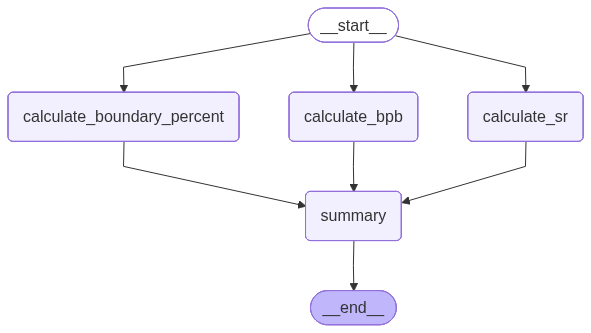

In [71]:
workflow

In [72]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}
workflow.invoke(initial_state)

{'runs': 100,
 'fours': 6,
 'sixes': 4,
 'balls': 50,
 'sr': 200.0,
 'boundary_percent': 0.48,
 'bpb': 5.0,
 'summary': '\nStrike Rate- 200.0 \n\nBoundary percent - 0.48 \n\nBalls Per boundary - 5.0\n'}